In [385]:
from typing import TypedDict , List
import random
from langgraph.graph import StateGraph,START,END

In [386]:
class AgentState(TypedDict):  #our state schema
    name : str
    number : list
    count : int

In [387]:
def greeting (state: AgentState)-> AgentState:
    """simple node that add greeting to the state"""   
    state["name"] = f"hi {state["name"]}"
    # state["count"]=0
    return state


def random_node (state: AgentState)-> AgentState:
    """generate a random number from 0 to 10"""   
    state["number"].append(random.randint(0,10))
    state["count"]+=1
    return state

def shouldcontinue (state: AgentState)-> AgentState:
    """function to check if the loop should continue"""
    if state["count"] < 5:
        print("entering loop", state["count"])
        return "loop"; 
    else:
        return "exit"



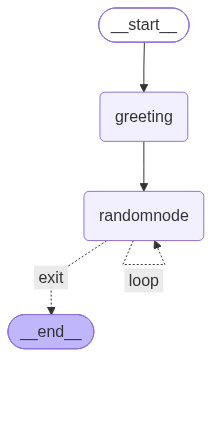

In [388]:
graph = StateGraph(AgentState)

graph.add_node("greeting",greeting)
graph.add_node("randomnode",random_node)

graph.add_edge("greeting","randomnode")

graph.add_conditional_edges(
    "randomnode",#source node
    shouldcontinue, #action
    {  #edges:node
        "loop":"randomnode", #self loop back to same node
        "exit":END #end the graph
    }
)

graph.set_entry_point("greeting")

app1 = graph.compile()

from IPython.display import display,Image
display(Image(app1.get_graph().draw_mermaid_png()))


In [389]:
app1.invoke({"name":"yash" , "number":[] ,"count":-4})


entering loop -3
entering loop -2
entering loop -1
entering loop 0
entering loop 1
entering loop 2
entering loop 3
entering loop 4


{'name': 'hi yash', 'number': [9, 2, 1, 3, 2, 2, 5, 6, 6], 'count': 5}

## excercise

In [390]:
class GameState(TypedDict):
    player_name: str
    target_number: int
    guesses: List[int]
    attempts: int
    hint: str
    lower_bound: int 
    upper_bound: int 

In [391]:
def setup_node(state: GameState) -> GameState:
    """Initialize the game with a random target number"""
    state["player_name"] = f"Welcome, {state['player_name']}!"
    state["target_number"] = random.randint(1, 20)
    state["guesses"] = []
    state["attempts"] = 0
    state["hint"] = "Game started! Try to guess the number."
    state["lower_bound"] = 1 
    state["upper_bound"] = 20 
    print(f"ypur target number is {state['target_number']}")
    print(f"{state['player_name']} The game has begun. I'm thinking of a number between 1 and 20.")
    return state

In [392]:
def guess_node (state: GameState) -> GameState:
    state["attempts"] += 1
    print(state["attempts"])
    state["guesses"].append(random.randint(state["lower_bound"],state["upper_bound"]))
    print(state["guesses"])

    return state    

In [393]:
def continue_node(state: GameState) -> GameState:
    if state["guesses"][-1] == state["target_number"]:
            print("you got the number in attempts: ",state["attempts"])
            return "end"
    if state["attempts"]>=7:
        return "end"
    else:
        return "loop"
        
    


In [394]:
def hint_node(state: GameState) -> GameState:
    
    if state["guesses"][-1]< state["target_number"]:
        state["hint"] = "number too low"
        print(state["hint"])
        state["lower_bound"]=state["guesses"][-1]
    else:
        state["hint"] = "number too high"
        print(state["hint"])
        state["upper_bound"] = state["guesses"][-1]

    return state

In [395]:
game = StateGraph(GameState)

game.add_node("setup",setup_node)
game.add_node("guess",guess_node)
game.add_node("hint",hint_node)

game.set_entry_point("setup")
game.add_edge("setup","guess")
game.add_edge("guess","hint")
game.add_conditional_edges(
    "hint",#source
    #action

    continue_node,{
        "loop":"guess",
        "end": END
    }
)

app = game.compile()


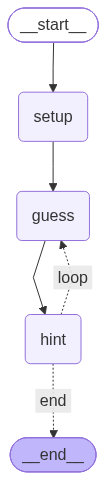

In [396]:
from IPython.display import display,Image
display(Image(app.get_graph().draw_mermaid_png()))

In [397]:
result = app.invoke({"player_name": "Student", "guesses": [], "attempts": 0, "lower_bound": 1, "upper_bound": 20})

ypur target number is 11
Welcome, Student! The game has begun. I'm thinking of a number between 1 and 20.
1
[19]
number too high
2
[19, 5]
number too low
3
[19, 5, 13]
number too high
4
[19, 5, 13, 11]
number too high
you got the number in attempts:  4
